# 03 — Customer Feature Engineering, RFM Analysis & Churn Labelling

**Phase 3** — Transforms `data/processed/qualified_transactions.csv` into a leakage-safe  
customer-level analytical dataset and generates the fixed `Churn_90D` target.

### Fixed dates (never derived from data)
| Constant | Value |
|---|---|
| SNAPSHOT_DATE | 2011-08-31 |
| OBSERVATION_START | 2010-12-01 |
| OBSERVATION_END | 2011-08-31 |
| FUTURE_START | 2011-09-01 |
| FUTURE_END | 2011-11-29 |

### Outputs
- `data/processed/customer_features.csv` — one row per eligible customer
- `data/processed/rfm_churn_summary.json` — concise statistics


## 1. Setup and Imports

In [1]:
import sys
import pathlib

# Ensure repo root is on sys.path when running from notebooks/
repo_root = pathlib.Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from src.config import (
    SNAPSHOT_DATE, OBSERVATION_START, OBSERVATION_END,
    FUTURE_START, FUTURE_END, PROCESSED_DIR
)
from src.data.load import load_qualified_transactions
from src.data.clean import get_eligible_customer_ids
from src.features.rfm import compute_customer_features, add_rfm_scores
from src.features.churn_label import generate_churn_label
from src.features.build_features import build_customer_features, save_customer_features, save_rfm_churn_summary

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)
print('Setup complete.')
print(f'SNAPSHOT_DATE : {SNAPSHOT_DATE.date()}')
print(f'FUTURE window : {FUTURE_START.date()} → {FUTURE_END.date()}')

Setup complete.
SNAPSHOT_DATE : 2011-08-31
FUTURE window : 2011-09-01 → 2011-11-29


## 2. Load Qualified Transactions

In [2]:
df_qualified = load_qualified_transactions()
print(f'Total qualified rows : {len(df_qualified):,}')
print(f'Date range           : {df_qualified["InvoiceDate"].min()} → {df_qualified["InvoiceDate"].max()}')
print(f'Unique customers     : {df_qualified["CustomerID"].nunique():,}')
print()
print('Sample:')
df_qualified.head(3)

Total qualified rows : 392,692
Date range           : 2010-12-01 08:26:00 → 2011-12-09 12:50:00
Unique customers     : 4,338

Sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancellation
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.00,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.00,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.00,United Kingdom,22.00,False


## 3. Split Observation and Future Windows

All date comparisons use **date-level** (`.dt.date`) logic so intraday
timestamps on boundary dates are correctly included.

In [3]:
_dates = df_qualified['InvoiceDate'].dt.date

df_obs = df_qualified[_dates <= SNAPSHOT_DATE.date()].copy()
df_future = df_qualified[
    (_dates >= FUTURE_START.date()) & (_dates <= FUTURE_END.date())
].copy()

print('=== Window Summary ===')
print(f'Observation transactions : {len(df_obs):,}')
print(f'  Date range             : {df_obs["InvoiceDate"].min().date()} → {df_obs["InvoiceDate"].max().date()}')
print(f'  Unique customers       : {df_obs["CustomerID"].nunique():,}')
print()
print(f'Future transactions      : {len(df_future):,}')
print(f'  Date range             : {df_future["InvoiceDate"].min().date()} → {df_future["InvoiceDate"].max().date()}')
print(f'  Unique customers       : {df_future["CustomerID"].nunique():,}')

=== Window Summary ===
Observation transactions : 224,036
  Date range             : 2010-12-01 → 2011-08-31
  Unique customers       : 3,317

Future transactions      : 149,526
  Date range             : 2011-09-01 → 2011-11-29
  Unique customers       : 2,839


## 4. Customer Eligibility

Eligibility is determined **exclusively** from the observation period.

| Condition | Rule |
|---|---|
| Minimum invoices | ≥ 2 distinct qualifying InvoiceNo values |
| Purchase span | ≥ 30 days between first and last purchase |

In [4]:
eligible_ids = get_eligible_customer_ids(df_obs, snapshot=SNAPSHOT_DATE)
n_eligible = len(eligible_ids)
n_obs_customers = df_obs['CustomerID'].nunique()

print(f'Observation-period customers  : {n_obs_customers:,}')
print(f'Eligible customers            : {n_eligible:,}')
print(f'Ineligible (filtered out)     : {n_obs_customers - n_eligible:,}')
print()
print('Expected eligible customers   : 1,765  (audit checkpoint)')
if n_eligible == 1765:
    print('✓ Matches audit checkpoint')
else:
    print(f'⚠ Discrepancy: got {n_eligible}')

Observation-period customers  : 3,317
Eligible customers            : 1,765
Ineligible (filtered out)     : 1,552

Expected eligible customers   : 1,765  (audit checkpoint)
✓ Matches audit checkpoint


## 5. Customer Feature Engineering

All features are derived **only** from `df_obs` (observation period). The future window is used exclusively for label generation.

In [5]:
df_eligible_obs = df_obs[df_obs['CustomerID'].isin(eligible_ids)].copy()
features = compute_customer_features(df_eligible_obs, snapshot=SNAPSHOT_DATE)
features = add_rfm_scores(features)

print(f'Feature table shape: {features.shape}')
print(f'Customers in feature table: {len(features):,}')
print()
print('Feature columns:', list(features.columns))

Feature table shape: (1765, 15)
Customers in feature table: 1,765

Feature columns: ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems', 'ActiveMonths', 'TenureDays', 'PurchaseSpanDays', 'Country', 'R', 'F', 'M', 'RFM_Score', 'RFM_Segment']


In [6]:
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
                'UniqueProducts', 'TotalItems', 'ActiveMonths',
                'TenureDays', 'PurchaseSpanDays']
features[numeric_cols].describe().round(2)

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems,ActiveMonths,TenureDays,PurchaseSpanDays
count,1765.00,1765.00,1765.00,1765.00,1765.00,1765.00,1765.00,1765.00,1765.00
mean,54.88,5.45,2555.49,399.53,72.95,1494.73,3.70,210.81,155.93
std,49.49,7.02,7782.53,531.96,80.99,4722.57,1.94,56.67,68.48
min,0.00,2.00,21.31,10.66,1.00,8.00,2.00,40.00,31.00
25%,15.00,2.00,623.28,195.65,27.00,327.00,2.00,171.00,100.00
50%,40.00,4.00,1132.62,306.99,53.00,652.00,3.00,220.00,156.00
75%,83.00,6.00,2191.78,437.01,92.00,1307.00,5.00,265.00,215.00
max,236.00,127.00,176355.94,14844.77,1190.00,126731.00,9.00,273.00,272.00


## 6. Churn Label Generation (Churn_90D)

The future window (`2011-09-01` – `2011-11-29`) is used **only** to assign the binary target.  
No future transaction data enters the feature set.

- **Churn_90D = 1**: no qualifying purchase in the future window
- **Churn_90D = 0**: at least one qualifying purchase in the future window

In [7]:
labels = generate_churn_label(df_qualified, eligible_ids)
features = features.join(labels, how='left')

n_total = len(features)
n_churned = int(features['Churn_90D'].sum())
n_active = int((features['Churn_90D'] == 0).sum())

print('=== Churn_90D Class Balance ===')
print(f'Total eligible customers : {n_total:,}')
print(f'Churn_90D = 1 (inactive) : {n_churned:,}  ({n_churned/n_total*100:.2f}%)')
print(f'Churn_90D = 0 (active)   : {n_active:,}  ({n_active/n_total*100:.2f}%)')
print()
print('Audit checkpoint: 490 inactive (27.76%), 1275 active (72.24%)')

assert features['Churn_90D'].isna().sum() == 0, 'ERROR: Missing Churn_90D values'
assert set(features['Churn_90D'].unique()).issubset({0, 1}), 'ERROR: Non-binary Churn_90D'
print('✓ Target integrity checks passed')

=== Churn_90D Class Balance ===
Total eligible customers : 1,765
Churn_90D = 1 (inactive) : 490  (27.76%)
Churn_90D = 0 (active)   : 1,275  (72.24%)

Audit checkpoint: 490 inactive (27.76%), 1275 active (72.24%)
✓ Target integrity checks passed


## 7. Save Outputs

In [8]:
# Reset index so CustomerID is a plain column
features_out = features.reset_index()

output_cols = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'UniqueProducts', 'TotalItems', 'ActiveMonths', 'TenureDays',
    'PurchaseSpanDays', 'Country', 'R', 'F', 'M',
    'RFM_Score', 'RFM_Segment', 'Churn_90D'
]
cols_present = [c for c in output_cols if c in features_out.columns]
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
csv_path = PROCESSED_DIR / 'customer_features.csv'
features_out[cols_present].to_csv(csv_path, index=False)
print(f'Saved: {csv_path}  ({len(features_out):,} rows)')

# rfm_churn_summary.json
rfm_score_dist = features['RFM_Score'].value_counts().sort_index().to_dict()
rfm_segment_counts = features['RFM_Segment'].value_counts().to_dict()
summary = {
    'snapshot_date': str(SNAPSHOT_DATE.date()),
    'observation_transaction_rows': int(len(df_obs)),
    'future_transaction_rows': int(len(df_future)),
    'eligible_customers': int(n_total),
    'rfm_score_distribution': {str(k): int(v) for k, v in rfm_score_dist.items()},
    'rfm_segment_counts': {str(k): int(v) for k, v in rfm_segment_counts.items()},
    'churn_90d': {
        'class_0_count': int(n_active),
        'class_1_count': int(n_churned),
        'class_0_pct': round(n_active / n_total * 100, 4),
        'class_1_pct': round(n_churned / n_total * 100, 4),
    },
    'rfm_feature_summary': {
        col: {
            'min': round(float(features[col].min()), 2),
            'max': round(float(features[col].max()), 2),
            'mean': round(float(features[col].mean()), 2),
            'median': round(float(features[col].median()), 2),
        }
        for col in ['Recency', 'Frequency', 'Monetary', 'RFM_Score']
    },
}
json_path = PROCESSED_DIR / 'rfm_churn_summary.json'
with open(json_path, 'w', encoding='utf-8') as fh:
    json.dump(summary, fh, indent=2)
print(f'Saved: {json_path}')

Saved: D:\IBM_SkillsBuild_Data_Analytics_AI_Internship_2026\ecommerce-churn-analytics\data\processed\customer_features.csv  (1,765 rows)
Saved: D:\IBM_SkillsBuild_Data_Analytics_AI_Internship_2026\ecommerce-churn-analytics\data\processed\rfm_churn_summary.json


## 8. RFM Distributions

### Q1: What are the distributions of Recency, Frequency and Monetary?

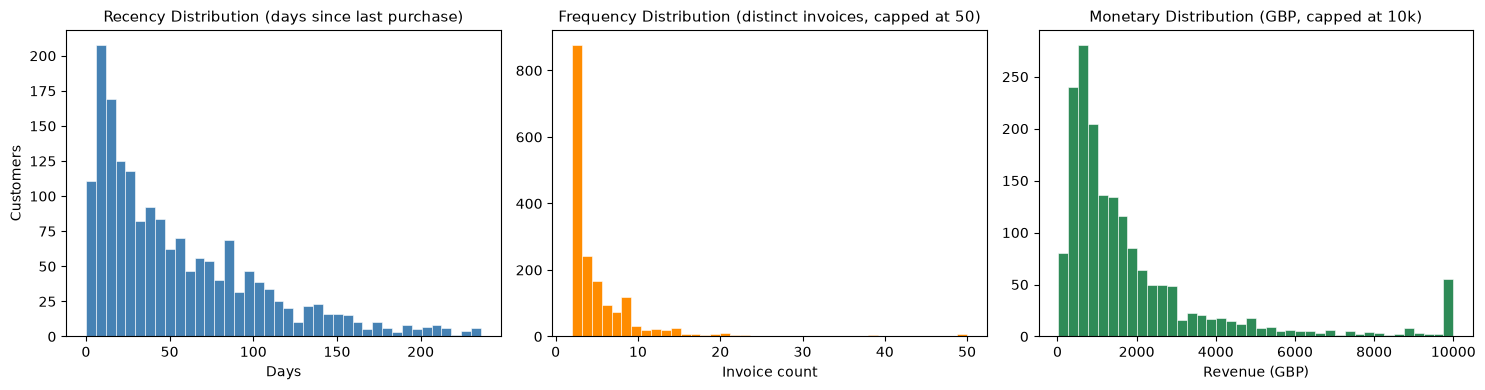

Recency  — median: 40.0  mean: 54.9
Frequency — median: 4.0  mean: 5.4
Monetary  — median: GBP 1132.62  mean: GBP 2555.49


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(features['Recency'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Recency Distribution (days since last purchase)', fontsize=11)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Customers')

axes[1].hist(features['Frequency'].clip(upper=50), bins=40, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_title('Frequency Distribution (distinct invoices, capped at 50)', fontsize=11)
axes[1].set_xlabel('Invoice count')

axes[2].hist(features['Monetary'].clip(upper=10000), bins=40, color='seagreen', edgecolor='white', linewidth=0.4)
axes[2].set_title('Monetary Distribution (GBP, capped at 10k)', fontsize=11)
axes[2].set_xlabel('Revenue (GBP)')

plt.tight_layout()
plt.show()

print('Recency  — median:', features['Recency'].median(), ' mean:', round(features['Recency'].mean(),1))
print('Frequency — median:', features['Frequency'].median(), ' mean:', round(features['Frequency'].mean(),1))
print('Monetary  — median: GBP', round(features['Monetary'].median(),2), ' mean: GBP', round(features['Monetary'].mean(),2))

## 9. RFM Score and Segment Distribution

### Q3: How are customers distributed across RFM groups?

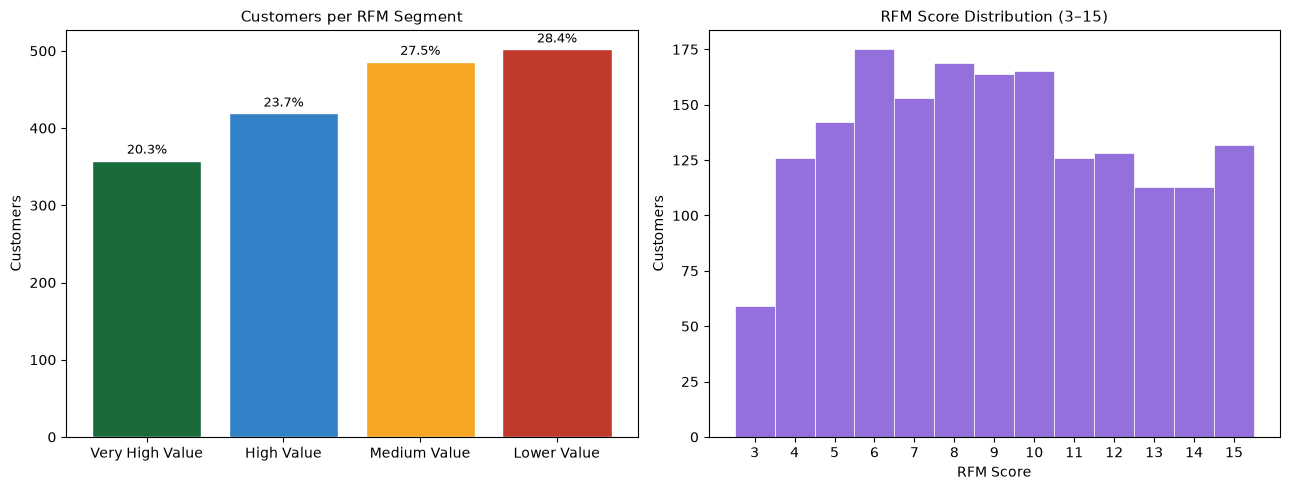

Segment counts:
  Very High Value   :  358  (20.3%)
  High Value        :  419  (23.7%)
  Medium Value      :  486  (27.5%)
  Lower Value       :  502  (28.4%)


In [10]:
segment_order = ['Very High Value', 'High Value', 'Medium Value', 'Lower Value']
seg_counts = features['RFM_Segment'].value_counts().reindex(segment_order).fillna(0).astype(int)
seg_pcts = (seg_counts / seg_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: segment counts
colors = ['#1a6b3c', '#3382c7', '#f5a623', '#c0392b']
bars = axes[0].bar(seg_counts.index, seg_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Customers per RFM Segment', fontsize=11)
axes[0].set_ylabel('Customers')
for bar, pct in zip(bars, seg_pcts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{pct}%', ha='center', va='bottom', fontsize=9)

# Histogram: RFM_Score
axes[1].hist(features['RFM_Score'], bins=range(3, 17), color='mediumpurple',
             edgecolor='white', linewidth=0.5, align='left')
axes[1].set_title('RFM Score Distribution (3–15)', fontsize=11)
axes[1].set_xlabel('RFM Score')
axes[1].set_ylabel('Customers')
axes[1].set_xticks(range(3, 16))

plt.tight_layout()
plt.show()

print('Segment counts:')
for seg in segment_order:
    print(f'  {seg:<18}: {seg_counts[seg]:4d}  ({seg_pcts[seg]:.1f}%)')

## 10. Recency Distribution Analysis

### Q7: How does inactivity vary across recency bands?

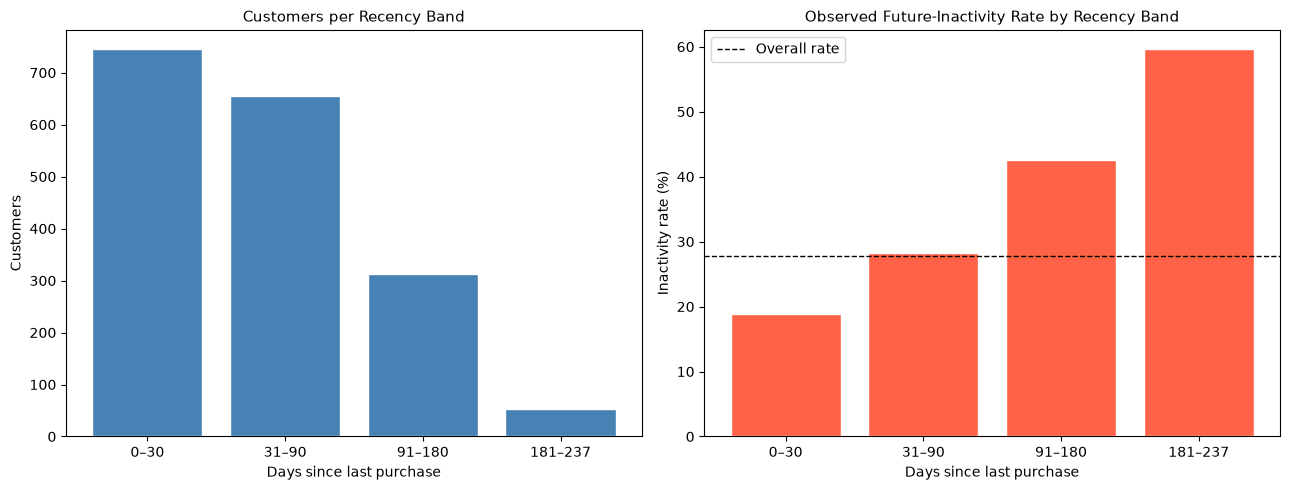

Recency band analysis:
             churned  total  inactive_rate_pct
RecencyBand                                   
0–30             141    745              18.90
31–90            185    656              28.20
91–180           133    312              42.60
181–237           31     52              59.60


In [11]:
# Dynamic bins — upper bound adapts to the actual max recency
_rec_max = int(features['Recency'].max()) + 1
_rec_bins = sorted(set([0, 30, 90, 180] + ([270] if _rec_max > 270 else []) +
                         ([365] if _rec_max > 365 else []) + [_rec_max]))
_rec_labels_map = {(0, 30): '0–30', (30, 90): '31–90', (90, 180): '91–180',
                   (180, 270): '181–270', (270, 365): '271–365', (365, _rec_max): '>365'}
_rec_labels = [_rec_labels_map.get((a, b), f'{a+1}–{b}') for a, b in zip(_rec_bins[:-1], _rec_bins[1:])]
features['RecencyBand'] = pd.cut(
    features['Recency'],
    bins=_rec_bins,
    labels=_rec_labels,
    right=True,
    include_lowest=True
)

recency_churn = (
    features.groupby('RecencyBand', observed=True)['Churn_90D']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'churned', 'count': 'total'})
)
recency_churn['inactive_rate_pct'] = (recency_churn['churned'] / recency_churn['total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(recency_churn.index.astype(str), recency_churn['total'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Customers per Recency Band', fontsize=11)
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Customers')

axes[1].bar(recency_churn.index.astype(str), recency_churn['inactive_rate_pct'],
            color='tomato', edgecolor='white')
axes[1].set_title('Observed Future-Inactivity Rate by Recency Band', fontsize=11)
axes[1].set_xlabel('Days since last purchase')
axes[1].set_ylabel('Inactivity rate (%)')
axes[1].axhline(features['Churn_90D'].mean()*100, color='black', linestyle='--',
                linewidth=1, label='Overall rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Recency band analysis:')
print(recency_churn.to_string())

## 11. Frequency Distribution Analysis

### Q8: How does inactivity vary across frequency groups?

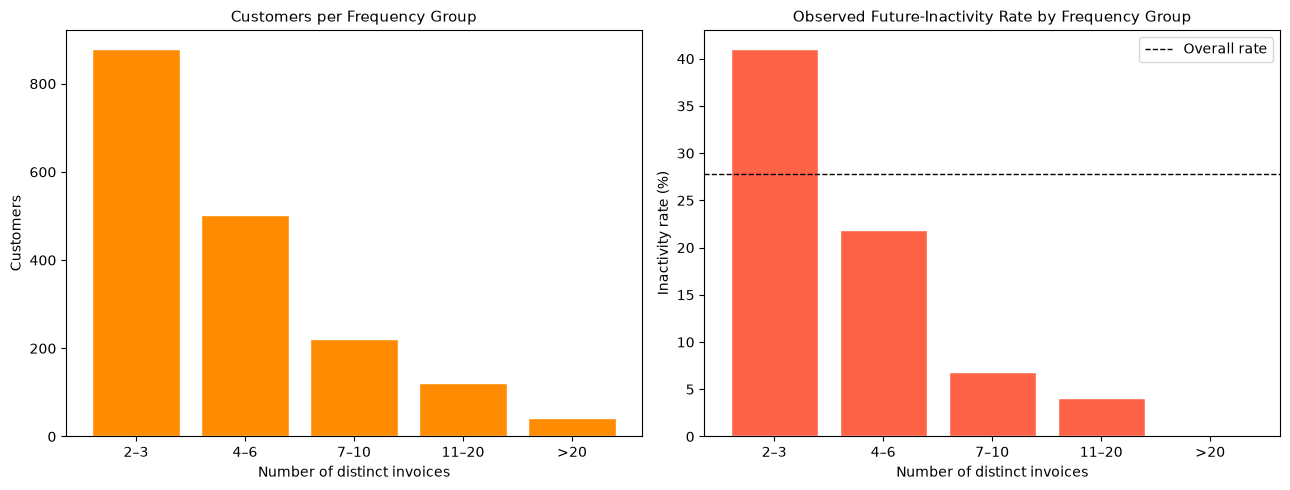

Frequency group analysis:
           churned  total  inactive_rate_pct
FreqGroup                                   
2–3            360    878              41.00
4–6            110    502              21.90
7–10            15    222               6.80
11–20            5    122               4.10
>20              0     41               0.00


In [12]:
freq_bins = [0, 3, 6, 10, 20, features['Frequency'].max() + 1]
features['FreqGroup'] = pd.cut(
    features['Frequency'],
    bins=freq_bins,
    labels=['2–3', '4–6', '7–10', '11–20', '>20'],
    right=True
)

freq_churn = (
    features.groupby('FreqGroup', observed=True)['Churn_90D']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'churned', 'count': 'total'})
)
freq_churn['inactive_rate_pct'] = (freq_churn['churned'] / freq_churn['total'] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(freq_churn.index.astype(str), freq_churn['total'],
            color='darkorange', edgecolor='white')
axes[0].set_title('Customers per Frequency Group', fontsize=11)
axes[0].set_xlabel('Number of distinct invoices')
axes[0].set_ylabel('Customers')

axes[1].bar(freq_churn.index.astype(str), freq_churn['inactive_rate_pct'],
            color='tomato', edgecolor='white')
axes[1].set_title('Observed Future-Inactivity Rate by Frequency Group', fontsize=11)
axes[1].set_xlabel('Number of distinct invoices')
axes[1].set_ylabel('Inactivity rate (%)')
axes[1].axhline(features['Churn_90D'].mean()*100, color='black', linestyle='--',
                linewidth=1, label='Overall rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Frequency group analysis:')
print(freq_churn.to_string())

## 12. Monetary Distribution Analysis

### Q2: Which customer segments generate the greatest historical revenue?
### Q9: How does inactivity differ between lower- and higher-value customers?

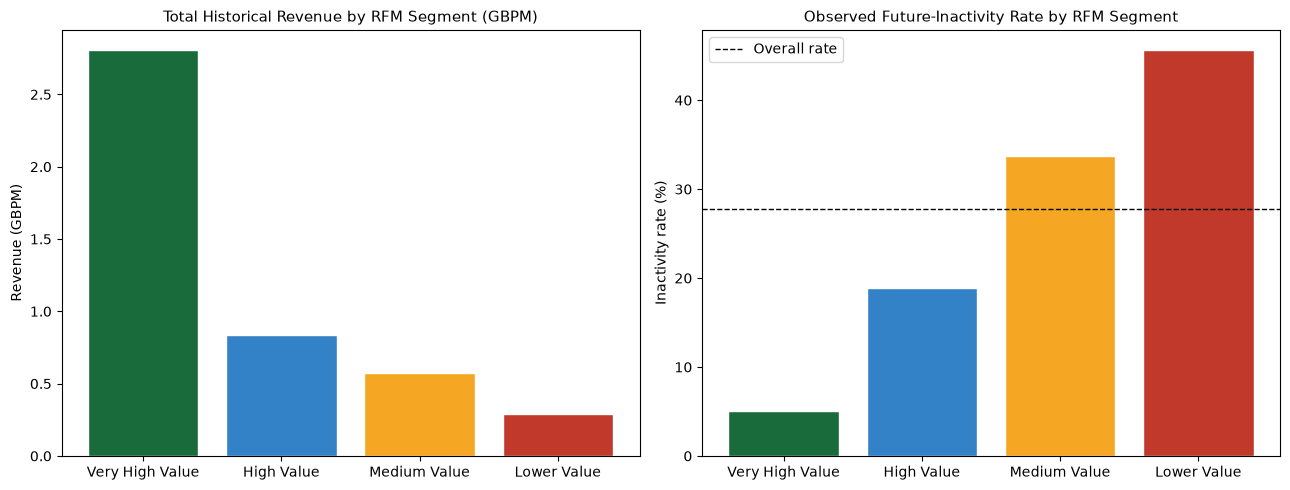

Revenue by RFM segment:
                 customers  total_revenue  avg_revenue  revenue_share_pct
RFM_Segment                                                              
Very High Value        358     2805416.71      7836.36              62.20
High Value             419      837449.35      1998.69              18.60
Medium Value           486      575087.73      1183.31              12.80
Lower Value            502      292479.06       582.63               6.50

Inactivity rate by RFM segment:
RFM_Segment
Very High Value    5.00
High Value        18.90
Medium Value      33.70
Lower Value       45.60


In [13]:
seg_revenue = (
    features.groupby('RFM_Segment', observed=True)['Monetary']
    .agg(['sum', 'mean', 'count'])
    .reindex(segment_order)
    .rename(columns={'sum': 'total_revenue', 'mean': 'avg_revenue', 'count': 'customers'})
)
seg_revenue['revenue_share_pct'] = (seg_revenue['total_revenue'] / seg_revenue['total_revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(seg_revenue.index, seg_revenue['total_revenue'] / 1e6,
            color=colors, edgecolor='white')
axes[0].set_title('Total Historical Revenue by RFM Segment (GBPM)', fontsize=11)
axes[0].set_ylabel('Revenue (GBPM)')

# Inactivity by segment
seg_churn = (
    features.groupby('RFM_Segment', observed=True)['Churn_90D']
    .mean() * 100
).reindex(segment_order)

axes[1].bar(seg_churn.index, seg_churn.values, color=colors, edgecolor='white')
axes[1].set_title('Observed Future-Inactivity Rate by RFM Segment', fontsize=11)
axes[1].set_ylabel('Inactivity rate (%)')
axes[1].axhline(features['Churn_90D'].mean()*100, color='black', linestyle='--',
                linewidth=1, label='Overall rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Revenue by RFM segment:')
print(seg_revenue[['customers', 'total_revenue', 'avg_revenue', 'revenue_share_pct']].round(2).to_string())
print()
print('Inactivity rate by RFM segment:')
print(seg_churn.round(1).to_string())

## 13. Relationships Between R, F and M

### Q5: How are R, F and M related?

In [14]:
corr = features[['Recency', 'Frequency', 'Monetary']].corr()
print('Correlation matrix (Recency, Frequency, Monetary):')
print(corr.round(3).to_string())
print()
print('Note: Recency is measured as days since last purchase — higher = older.')
print('A negative Recency–Frequency correlation indicates more frequent buyers')
print('tend to have lower recency (i.e., purchased more recently).')

Correlation matrix (Recency, Frequency, Monetary):
           Recency  Frequency  Monetary
Recency       1.00      -0.28     -0.15
Frequency    -0.28       1.00      0.53
Monetary     -0.15       0.53      1.00

Note: Recency is measured as days since last purchase — higher = older.
A negative Recency–Frequency correlation indicates more frequent buyers
tend to have lower recency (i.e., purchased more recently).


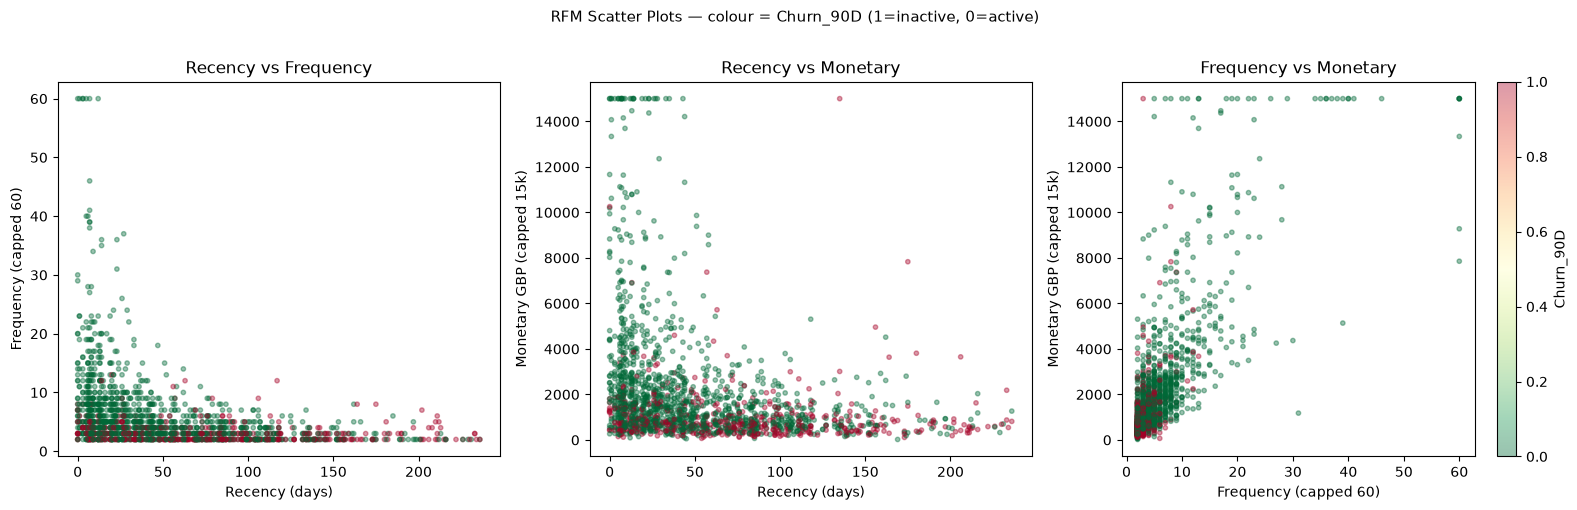

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

freq_cap = features['Frequency'].clip(upper=60)
mon_cap = features['Monetary'].clip(upper=15000)

axes[0].scatter(features['Recency'], freq_cap,
                c=features['Churn_90D'], cmap='RdYlGn_r', alpha=0.4, s=10)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Frequency (capped 60)')
axes[0].set_title('Recency vs Frequency')

axes[1].scatter(features['Recency'], mon_cap,
                c=features['Churn_90D'], cmap='RdYlGn_r', alpha=0.4, s=10)
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary GBP (capped 15k)')
axes[1].set_title('Recency vs Monetary')

sc = axes[2].scatter(freq_cap, mon_cap,
                     c=features['Churn_90D'], cmap='RdYlGn_r', alpha=0.4, s=10)
axes[2].set_xlabel('Frequency (capped 60)')
axes[2].set_ylabel('Monetary GBP (capped 15k)')
axes[2].set_title('Frequency vs Monetary')

cbar = fig.colorbar(sc, ax=axes[2])
cbar.set_label('Churn_90D')

plt.suptitle('RFM Scatter Plots — colour = Churn_90D (1=inactive, 0=active)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

## 14. Quartile / Distribution Analysis

In [16]:
quartile_summary = features[['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
                              'TenureDays', 'PurchaseSpanDays', 'ActiveMonths']].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.90]
).round(1)

print('Decile / quartile summary:')
quartile_summary

Decile / quartile summary:


,Recency,Frequency,Monetary,AvgOrderValue,TenureDays,PurchaseSpanDays,ActiveMonths
0.10,7.00,2.00,378.80,139.30,129.00,61.00,2.00
0.25,15.00,2.00,623.30,195.60,171.00,100.00,2.00
0.50,40.00,4.00,1132.60,307.00,220.00,156.00,3.00
0.75,83.00,6.00,2191.80,437.00,265.00,215.00,5.00
0.90,126.60,10.00,4341.80,704.50,269.00,252.00,7.00


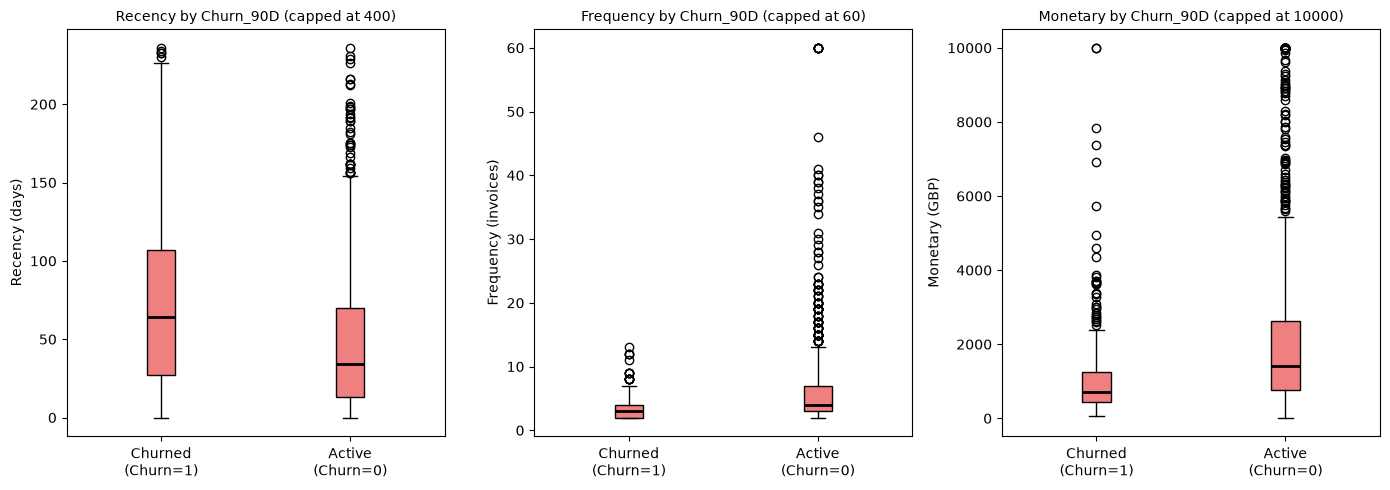

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

inactive = features[features['Churn_90D'] == 1]
active = features[features['Churn_90D'] == 0]

for ax, col, cap, unit in [
    (axes[0], 'Recency', 400, 'days'),
    (axes[1], 'Frequency', 60, 'invoices'),
    (axes[2], 'Monetary', 10000, 'GBP')
]:
    bp = ax.boxplot(
        [inactive[col].clip(upper=cap), active[col].clip(upper=cap)],
        patch_artist=True,
        boxprops=dict(facecolor='lightcoral'),
        medianprops=dict(color='black', linewidth=2),
    )
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Churned\n(Churn=1)', 'Active\n(Churn=0)'])
    ax.set_title(f'{col} by Churn_90D (capped at {cap})', fontsize=10)
    ax.set_ylabel(f'{col} ({unit})')

plt.tight_layout()
plt.show()

## 15. Future Inactivity by RFM Segment

### Q4: Which RFM groups show higher future inactivity?

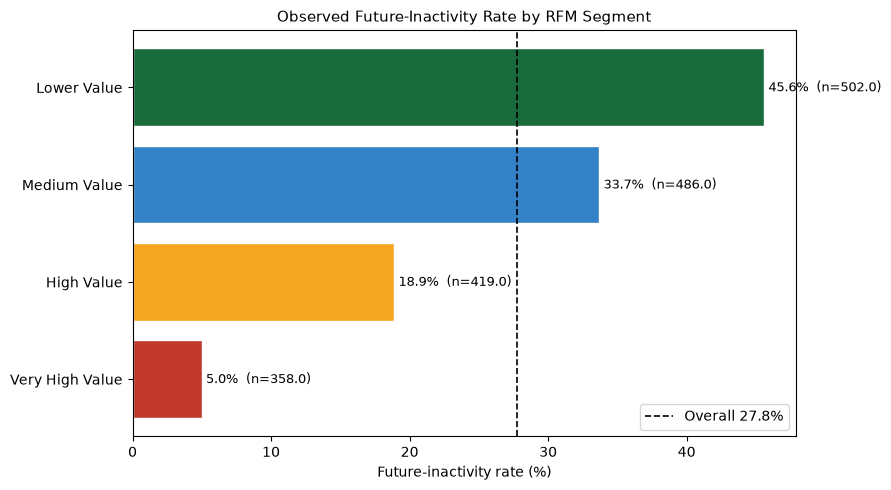

Inactivity by RFM segment:
                 customers  churned  active  inactivity_rate_pct
RFM_Segment                                                     
Very High Value        358       18     340                 5.00
High Value             419       79     340                18.90
Medium Value           486      164     322                33.70
Lower Value            502      229     273                45.60


In [18]:
churn_by_rfm = (
    features.groupby('RFM_Segment', observed=True)['Churn_90D']
    .agg(['mean', 'count', 'sum'])
    .rename(columns={'mean': 'inactivity_rate', 'count': 'customers', 'sum': 'churned'})
    .reindex(segment_order)
)
churn_by_rfm['active'] = churn_by_rfm['customers'] - churn_by_rfm['churned']
churn_by_rfm['inactivity_rate_pct'] = (churn_by_rfm['inactivity_rate'] * 100).round(1)

overall_rate = features['Churn_90D'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(churn_by_rfm.index, churn_by_rfm['inactivity_rate_pct'],
               color=colors[::-1], edgecolor='white')
ax.axvline(overall_rate, color='black', linestyle='--', linewidth=1.2, label=f'Overall {overall_rate:.1f}%')
ax.set_xlabel('Future-inactivity rate (%)')
ax.set_title('Observed Future-Inactivity Rate by RFM Segment', fontsize=11)
ax.legend()

for bar, (idx, row) in zip(bars, churn_by_rfm.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['inactivity_rate_pct']:.1f}%  (n={row['customers']})",
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Inactivity by RFM segment:')
print(churn_by_rfm[['customers', 'churned', 'active', 'inactivity_rate_pct']].to_string())

## 16. Class Balance Summary

### Q6: What proportion of eligible customers become inactive?

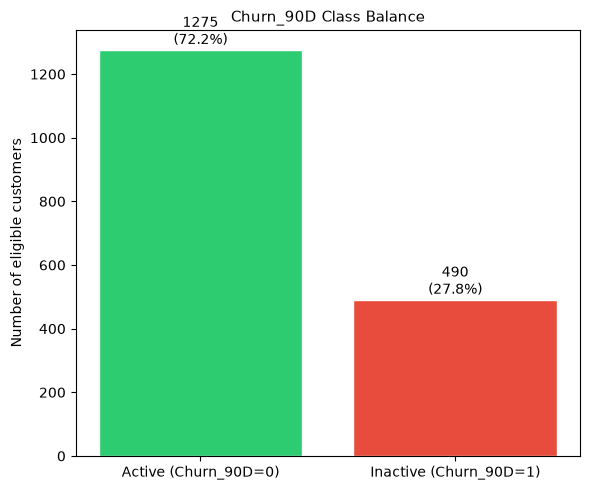

=== Churn_90D Target Summary ===
Eligible customers   : 1,765
Active (class 0)     : 1,275  (72.24%)
Inactive (class 1)   : 490  (27.76%)
Class imbalance ratio: 2.60:1 (active:inactive)


In [19]:
class_counts = features['Churn_90D'].value_counts().sort_index()
class_pcts = (class_counts / len(features) * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ['Active (Churn_90D=0)', 'Inactive (Churn_90D=1)'],
    class_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white'
)
for bar, count, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Churn_90D Class Balance', fontsize=11)
ax.set_ylabel('Number of eligible customers')
plt.tight_layout()
plt.show()

print('=== Churn_90D Target Summary ===')
print(f'Eligible customers   : {len(features):,}')
print(f'Active (class 0)     : {int(class_counts[0]):,}  ({class_pcts[0]:.2f}%)')
print(f'Inactive (class 1)   : {int(class_counts[1]):,}  ({class_pcts[1]:.2f}%)')
print(f'Class imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1 (active:inactive)')

## 17. Analytical Question Answers

Answers based on computed results — no manufactured conclusions.

In [20]:
rec_med = features['Recency'].median()
freq_med = features['Frequency'].median()
mon_med = features['Monetary'].median()
top_seg_rev = seg_revenue['total_revenue'].idxmax()
top_seg_rev_pct = seg_revenue.loc[top_seg_rev, 'revenue_share_pct']
churn_rate = features['Churn_90D'].mean() * 100

# Inactivity by recency band
highest_inactive_rb = recency_churn['inactive_rate_pct'].idxmax()
highest_inactive_rb_rate = recency_churn.loc[highest_inactive_rb, 'inactive_rate_pct']
lowest_inactive_rb = recency_churn['inactive_rate_pct'].idxmin()
lowest_inactive_rb_rate = recency_churn.loc[lowest_inactive_rb, 'inactive_rate_pct']

# Inactivity by frequency group
highest_inactive_fg = freq_churn['inactive_rate_pct'].idxmax()
highest_inactive_fg_rate = freq_churn.loc[highest_inactive_fg, 'inactive_rate_pct']

print('=== ANALYTICAL QUESTION ANSWERS ===')
print()
print('Q1. Distributions of Recency, Frequency and Monetary:')
print(f'    Recency   — median {rec_med:.0f} days (right-skewed; many customers purchased recently)')
print(f'    Frequency — median {freq_med:.0f} invoices (heavily right-skewed; most customers have few invoices)')
print(f'    Monetary  — median GBP{mon_med:.2f} (right-skewed; a small number of high-value customers dominate)')
print()
print(f'Q2. Highest historical revenue segment: {top_seg_rev} ({top_seg_rev_pct:.1f}% of total revenue)')
print()
print('Q3. RFM segment distribution:')
for seg in segment_order:
    print(f'    {seg:<18}: {seg_counts[seg]:4d} customers ({seg_pcts[seg]:.1f}%)')
print()
print('Q4. Inactivity by RFM segment (see Section 15 chart):')
for seg in segment_order:
    rate = churn_by_rfm.loc[seg, 'inactivity_rate_pct']
    print(f'    {seg:<18}: {rate:.1f}% inactivity rate')
print()
print('Q5. R-F-M correlations:')
print(f'    Recency–Frequency: {corr.loc["Recency","Frequency"]:.3f}')
print(f'    Recency–Monetary:  {corr.loc["Recency","Monetary"]:.3f}')
print(f'    Frequency–Monetary:{corr.loc["Frequency","Monetary"]:.3f}')
print()
print(f'Q6. {churn_rate:.2f}% of eligible customers show no qualifying purchase in the future window')
print()
print(f'Q7. Future-inactivity rate is highest in the "{highest_inactive_rb}" day recency band '
      f'({highest_inactive_rb_rate:.1f}%); lowest in the "{lowest_inactive_rb}" band '
      f'({lowest_inactive_rb_rate:.1f}%).')
print()
print(f'Q8. Customers in the "{highest_inactive_fg}" invoice frequency group are associated with '
      f'the highest inactivity rate ({highest_inactive_fg_rate:.1f}%).')
print()
print('Q9. Inactivity by value group — use the RFM segment as proxy for customer value:')
lower_val_rate = churn_by_rfm.loc['Lower Value', 'inactivity_rate_pct'] if 'Lower Value' in churn_by_rfm.index else 'N/A'
very_high_rate  = churn_by_rfm.loc['Very High Value', 'inactivity_rate_pct'] if 'Very High Value' in churn_by_rfm.index else 'N/A'
print(f'    Lower Value customers have a {lower_val_rate}% inactivity rate;')
print(f'    Very High Value customers have a {very_high_rate}% inactivity rate.')
print()
print('Note: All relationships above are observational/associative; no causal inference is drawn.')

=== ANALYTICAL QUESTION ANSWERS ===

Q1. Distributions of Recency, Frequency and Monetary:
    Recency   — median 40 days (right-skewed; many customers purchased recently)
    Frequency — median 4 invoices (heavily right-skewed; most customers have few invoices)
    Monetary  — median GBP1132.62 (right-skewed; a small number of high-value customers dominate)

Q2. Highest historical revenue segment: Very High Value (62.2% of total revenue)

Q3. RFM segment distribution:
    Very High Value   :  358 customers (20.3%)
    High Value        :  419 customers (23.7%)
    Medium Value      :  486 customers (27.5%)
    Lower Value       :  502 customers (28.4%)

Q4. Inactivity by RFM segment (see Section 15 chart):
    Very High Value   : 5.0% inactivity rate
    High Value        : 18.9% inactivity rate
    Medium Value      : 33.7% inactivity rate
    Lower Value       : 45.6% inactivity rate

Q5. R-F-M correlations:
    Recency–Frequency: -0.281
    Recency–Monetary:  -0.153
    Frequency–M

## 18. Target Integrity and Leakage Verification

In [21]:
print('=== TARGET INTEGRITY CHECKS ===')

# 1. One row per eligible customer
csv_df = pd.read_csv(PROCESSED_DIR / 'customer_features.csv')
dup_check = csv_df['CustomerID'].nunique() == len(csv_df)
print(f'✓ No duplicate CustomerIDs: {dup_check}')

# 2. No missing Churn_90D
missing_target = csv_df['Churn_90D'].isna().sum()
print(f'✓ Missing Churn_90D: {missing_target} (expected 0)')

# 3. Binary target
valid_values = set(csv_df['Churn_90D'].unique()).issubset({0, 1})
print(f'✓ Churn_90D values are binary (0/1 only): {valid_values}')

# 4. No ineligible customers
print(f'✓ Rows = eligible customer count: {len(csv_df) == n_eligible}  ({len(csv_df)} rows)')

# 5. Leakage check — no post-snapshot predictor columns
forbidden_cols = [
    'FutureOrderCount', 'FutureRevenue', 'FutureRecency',
    'FutureFrequency', 'FutureProducts', 'future_purchase_count'
]
leaked = [c for c in forbidden_cols if c in csv_df.columns]
print(f'✓ No future-data columns in CSV: {len(leaked)==0}  (checked: {forbidden_cols[:3]}...)')

# 6. Required columns present
required_cols = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'UniqueProducts', 'TotalItems', 'ActiveMonths', 'TenureDays',
    'PurchaseSpanDays', 'Country', 'R', 'F', 'M',
    'RFM_Score', 'RFM_Segment', 'Churn_90D'
]
missing_cols = [c for c in required_cols if c not in csv_df.columns]
print(f'✓ All required columns present: {len(missing_cols)==0}')
if missing_cols:
    print(f'  Missing: {missing_cols}')

print()
print('=== FINAL SUMMARY ===')
print(f'Observation transactions : {len(df_obs):,}')
print(f'Future transactions      : {len(df_future):,}')
print(f'Eligible customers       : {len(csv_df):,}')
print(f'Churn_90D=1 (inactive)   : {int(csv_df["Churn_90D"].sum()):,} ({csv_df["Churn_90D"].mean()*100:.2f}%)')
print(f'Churn_90D=0 (active)     : {int((csv_df["Churn_90D"]==0).sum()):,} ({(csv_df["Churn_90D"]==0).mean()*100:.2f}%)')
print(f'RFM_Score range          : {csv_df["RFM_Score"].min()} – {csv_df["RFM_Score"].max()}')
print()
print('Phase 3 complete. Next: Phase 4 — Logistic Regression model training.')

=== TARGET INTEGRITY CHECKS ===
✓ No duplicate CustomerIDs: True
✓ Missing Churn_90D: 0 (expected 0)
✓ Churn_90D values are binary (0/1 only): True
✓ Rows = eligible customer count: True  (1765 rows)
✓ No future-data columns in CSV: True  (checked: ['FutureOrderCount', 'FutureRevenue', 'FutureRecency']...)
✓ All required columns present: True

=== FINAL SUMMARY ===
Observation transactions : 224,036
Future transactions      : 149,526
Eligible customers       : 1,765
Churn_90D=1 (inactive)   : 490 (27.76%)
Churn_90D=0 (active)     : 1,275 (72.24%)
RFM_Score range          : 3 – 15

Phase 3 complete. Next: Phase 4 — Logistic Regression model training.
